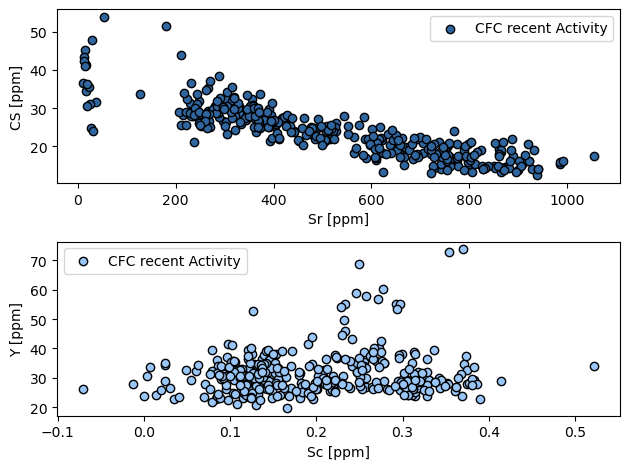

In [ ]:
import pandas as pd #untuk membaca file excel
import matplotlib.pyplot as plt #untuk membuat visualisasi data

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces') #membaca file excel dan menyimpan data pada variabel my_dataset

fig = plt.figure() #membuat figure untuk visualisasi data
ax1 = fig.add_subplot(2,1,1) #menambahkan subplot pada figure dengan 2 baris dan 1 kolom, dan memilih subplot pertama untuk visualisasi data
ax1.scatter(my_dataset.Sr, my_dataset.Cs, marker='o', edgecolor='k', color="#3066A0", label='CFC recent Activity') #visualisasi data dengan menggunakan scatter plot, dengan sumbu x adalah Sr dan sumbu y adalah Cs, serta memberikan label pada data
ax1.set_xlabel('Sr [ppm]') #memberikan label pada sumbu x dengan satuan ppm
ax1.set_ylabel('CS [ppm]')
ax1.legend() #menambahkan legenda pada visualisasi data

ax2 = fig.add_subplot(2,1,2)
ax2.scatter(my_dataset.Sc, my_dataset.Y, marker='o', edgecolor='k', color="#99c6f7", label='CFC recent Activity')
ax2.set_xlabel('Sc [ppm]')
ax2.set_ylabel('Y [ppm]')
ax2.legend()

plt.tight_layout() #mengatur tata letak visualisasi data agar tidak saling tumpang tindih

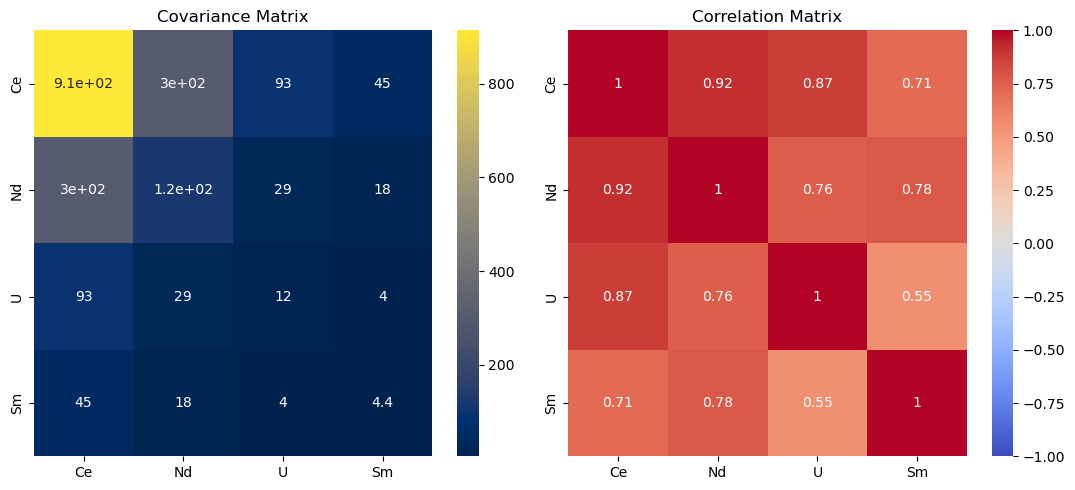

In [ ]:
import pandas as pd #untuk membaca file excel
import matplotlib.pyplot as  plt #untuk membuat visualisasi data
import seaborn as sns #untuk membuat visualisasi data dengan menggunakan heatmap untuk menampilkan matriks kovarians dan korelasi

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces') #membaca file excel dan menyimpan data pada variabel my_dataset

my_sub_dataset = my_dataset[['Ce','Nd','U','Sm']] #memilih kolom-kolom yang akan digunakan untuk analisis kovarians dan korelasi, yaitu kolom Ce, Nd, U, dan Sm, dan menyimpan data pada variabel my_sub_dataset

cov = my_sub_dataset.cov() #menghitung matriks kovarians dari data pada variabel my_sub_dataset dan menyimpan hasilnya pada variabel cov
cor = my_sub_dataset.corr()

fig = plt.figure(figsize=(11,5)) #menentukan ukuran figure untuk visualisasi data, dengan lebar 11 inci dan tinggi 5 inci   

ax1 = fig.add_subplot(1,2,1) #menambahkan subplot pada figure dengan 1 baris dan 2 kolom, dan memilih subplot pertama untuk visualisasi data
ax1.set_title('Covariance Matrix') #memberikan judul pada subplot pertama dengan judul 'Covariance Matrix'
sns.heatmap(cov, annot=True, cmap='cividis', ax=ax1) #visualisasi data dengan menggunakan heatmap untuk menampilkan matriks kovarians, dengan menggunakan colormap 'cividis' dan menampilkan nilai pada setiap sel dengan annot=True

ax2 = fig.add_subplot(1,2,2)
ax2.set_title('Correlation Matrix')
sns.heatmap(cor, annot=True, vmin= -1, vmax=1,  cmap='coolwarm', ax=ax2) 

fig.tight_layout() #mengatur tata letak visualisasi data agar tidak saling tumpang tindih, dengan menggunakan metode tight_layout() pada objek figure

plt.show()  #menampilkan visualisasi data dengan menggunakan metode show() pada objek plt

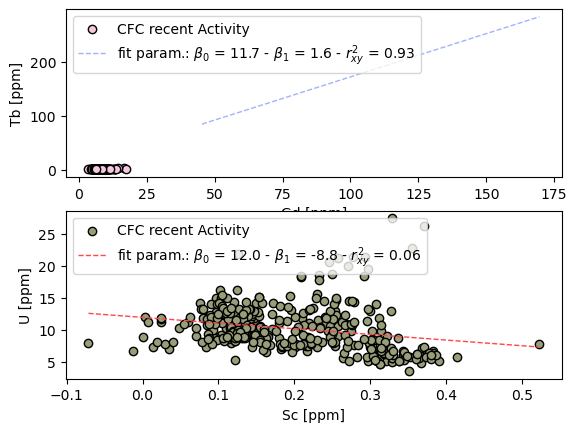

In [11]:
import pandas as pd #untuk membaca file excel  
import scipy.stats as st #untuk melakukan analisis regresi linier pada data, dengan menggunakan fungsi linregress dari modul scipy.stats
import numpy as np #untuk melakukan operasi matematika pada array, seperti membuat array linier untuk visualisasi data pada plot regresi linier
import matplotlib.pyplot as plt #untuk membuat visualisasi data, seperti scatter plot dan plot regresi linier, dengan menggunakan modul matplotlib.pyplot

my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces') #membaca file excel dan menyimpan data pada variabel my_dataset

fig = plt.figure() #membuat figure untuk visualisasi data
ax1= fig.add_subplot(2,1,1) #menambahkan subplot pada figure dengan 2 baris dan 1 kolom, dan memilih subplot pertama untuk visualisasi data
ax1.scatter(my_dataset.Gd, my_dataset.Tb, marker='o', edgecolor='k', color="#f4c7dd", label='CFC recent Activity') #visualisasi data dengan menggunakan scatter plot, dengan sumbu x adalah Gd dan sumbu y adalah Tb, serta memberikan label pada data
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.La, my_dataset.Ce) #melakukan analisis regresi linier pada data dengan menggunakan fungsi linregress dari modul scipy.stats, dengan sumbu x adalah La dan sumbu y adalah Ce, serta menyimpan hasil analisis pada variabel b1, b0, rho_value, p_value, dan std_err
x = np.linspace(my_dataset.La.min(),my_dataset.La.max()) #membuat array linier untuk visualisasi data pada plot regresi linier, dengan menggunakan fungsi linspace dari modul numpy, dengan batas bawah adalah nilai minimum dari La dan batas atas adalah nilai maksimum dari La
y = b0 + b1*x #menghitung nilai y untuk plot regresi linier dengan menggunakan persamaan garis lurus, yaitu y = b0 + b1*x, dengan b0 adalah intercept dan b1 adalah slope dari garis regresi linier
ax1.plot(x, y, linewidth=1, color="#a0b4f8", linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))
ax1.set_xlabel('Gd [ppm]')
ax1.set_ylabel('Tb [ppm]') #memberikan label pada sumbu y dengan satuan ppm
ax1.legend(loc= 'upper left') #menambahkan legenda pada visualisasi data dengan menggunakan metode legend() pada objek ax1, dan menentukan posisi legenda di bagian kiri atas dengan menggunakan parameter loc='upper left'

ax2 = fig.add_subplot(2,1,2)
ax2.scatter(my_dataset.Sc, my_dataset.U, marker='o', edgecolor='k', color="#989e79", label='CFC recent Activity')
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.Sc, my_dataset.U)
x = np.linspace(my_dataset.Sc.min(),my_dataset.Sc.max())
y = b0 + b1*x
ax2.plot(x, y, linewidth=1, color="#ff464a", linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))
ax2.set_xlabel('Sc [ppm]')
ax2.set_ylabel('U [ppm]')
ax2.legend(loc= 'upper left')



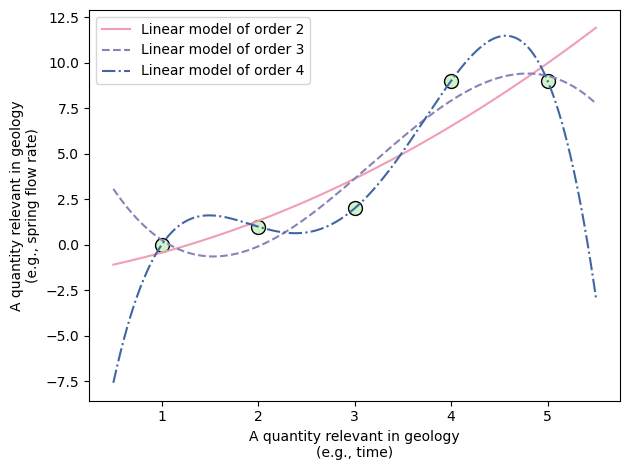

In [12]:
import numpy as np #untuk melakukan operasi matematika pada array, seperti membuat array linier untuk visualisasi data pada plot regresi linier
import matplotlib.pyplot as plt #untuk membuat visualisasi data, seperti scatter plot dan plot regresi linier, dengan menggunakan modul matplotlib.pyplot

x = np.arange(1,6) # membuat array x dengan menggunakan fungsi arange dari modul numpy, dengan nilai mulai dari 1 hingga 5 (tidak termasuk 6), yang akan digunakan sebagai sumbu x pada plot regresi linier
y = np.array([0,1,2,9,9])

fig, ax = plt.subplots() # membuat figure dan axes untuk visualisasi data dengan menggunakan fungsi subplots dari modul matplotlib.pyplot, yang akan digunakan untuk membuat scatter plot dan plot regresi linier
ax.scatter(x, y, marker = 'o', s = 100, color = "#cff4c7", edgecolor = 'k') #visualisasi data dengan menggunakan scatter plot, dengan sumbu x adalah array x dan sumbu y adalah array y, serta memberikan marker berbentuk lingkaran ('o'), ukuran marker sebesar 100, warna marker "#cff4c7", dan warna tepi marker 'k' (hitam)

orders = np.array([2,3,4]) # membuat array orders dengan menggunakan fungsi array dari modul numpy, yang berisi nilai-nilai 2, 3, dan 4, yang akan digunakan untuk menentukan orde dari model regresi polinomial yang akan dibuat pada plot regresi linier
colors =["#f09eb6","#8982b9","#4265a6"]
linestiles = ['-','--','-.']

for order, color, linestile in zip(orders, colors, linestiles): #melakukan iterasi untuk setiap nilai order, color, dan linestile yang diambil dari array orders, colors, dan linestiles secara bersamaan dengan menggunakan fungsi zip, yang akan digunakan untuk membuat plot regresi polinomial dengan orde yang berbeda-beda pada visualisasi data
    betas = np.polyfit(x, y, order) #menghitung koefisien regresi polinomial dengan menggunakan fungsi polyfit dari modul numpy, dengan sumbu x adalah array x, sumbu y adalah array y, dan orde dari model regresi polinomial yang ditentukan oleh variabel order, serta menyimpan hasil perhitungan pada variabel betas
    func = np.poly1d(betas) #membuat fungsi polinomial dengan menggunakan fungsi poly1d dari modul numpy, dengan koefisien regresi polinomial yang disimpan pada variabel betas, yang akan digunakan untuk menghitung nilai y pada plot regresi polinomial
    x1 = np.linspace(0.5,5.5, 1000) #membuat array x1 dengan menggunakan fungsi linspace dari modul numpy, dengan nilai mulai dari 0.5 hingga 5.5, dan jumlah nilai sebanyak 1000, yang akan digunakan sebagai sumbu x pada plot regresi polinomial
    y1 = func(x1)
    ax.plot(x1, y1, color=color, linestyle=linestile, label="Linear model of order " + str(order)) #visualisasi data dengan menggunakan plot, dengan sumbu x adalah array x1 dan sumbu y adalah array y1 yang dihitung dengan fungsi polinomial, serta memberikan warna pada plot sesuai dengan variabel color, jenis garis sesuai dengan variabel linestile, dan label pada plot sesuai dengan string "Linear model of order " yang diikuti oleh nilai order yang diubah menjadi string dengan menggunakan fungsi str

ax.legend() #menambahkan legenda pada visualisasi data dengan menggunakan metode legend() pada objek ax, yang akan menampilkan label pada setiap plot regresi polinomial yang dibuat pada visualisasi data
ax.set_xlabel('A quantity relevant in geology\n(e.g., time)') #memberikan label pada sumbu x dengan teks 'A quantity relevant in geology\n(e.g., time)', yang menjelaskan bahwa sumbu x mewakili suatu kuantitas yang relevan dalam geologi, seperti waktu, dengan menggunakan karakter newline (\n) untuk memisahkan teks menjadi dua baris
ax.set_ylabel('A quantity relevant in geology\n(e.g., spring flow rate)') 
fig.tight_layout()  #mengatur tata letak visualisasi data agar tidak saling tumpang tindih, dengan menggunakan metode tight_layout() pada objek figure


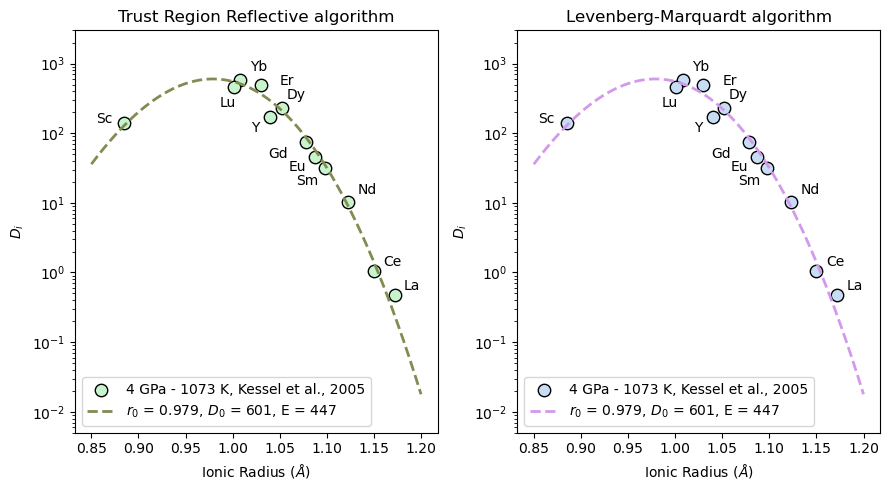

In [ ]:
import numpy as np #untuk melakukan operasi matematika pada array, seperti membuat array linier untuk visualisasi data pada plot regresi linier
import matplotlib.pyplot as plt #untuk membuat visualisasi data, seperti scatter plot dan plot regresi linier, dengan menggunakan modul matplotlib.pyplot
from scipy.optimize import curve_fit #untuk melakukan fitting kurva pada data dengan menggunakan fungsi curve_fit dari modul scipy.optimize, yang akan digunakan untuk menentukan parameter-parameter dari fungsi yang akan difitting pada data

def func(r, r0, D0, E): #fungsi yang akan digunakan untuk fitting kurva pada data, dengan parameter r sebagai variabel independen, dan r0, D0, E sebagai parameter yang akan ditentukan dengan fitting kurva
    R=8.314462618 #konstanta gas ideal dalam satuan J/(mol*K)
    scale = 1e-21 # r in Angstrom (r^3 -> 10^-30 m), E is GPa (10^9 Pa)
    T = 800 + 273.15 #temperatur dalam satuan Kelvin, dengan mengkonversi dari 800 derajat Celsius dengan menambahkan 273.15
    Na=6.02e23 #bilangan Avogadro dalam satuan mol^-1, yang digunakan untuk menghitung jumlah partikel dalam satu mol zat, dengan nilai 6.02 x 10^23 partikel per mol
    return D0*np.exp((-4*np.pi*E*Na*((r0/2)*(r-r0)**2+(1/3)*(r-r0)**3)*scale)/(R*T)) #fungsi yang akan digunakan untuk fitting kurva pada data, dengan menggunakan persamaan yang melibatkan parameter r0, D0, E, serta konstanta gas ideal R, skala untuk konversi satuan, temperatur T, dan bilangan Avogadro Na

def add_elements(ax): #fungsi untuk menambahkan anotasi pada plot dengan menggunakan metode annotate() pada objek ax, yang akan
    # to plot the name of the elements on the diagram
    names = ['La', 'Ce', 'Nd', 'Sm', 'Eu', 'Gd', 'Dy', 'Er', 'Yb', 'Lu', 'Y', 'Sc'] #daftar nama elemen yang akan digunakan untuk anotasi pada plot, dengan menggunakan simbol-simbol kimia dari elemen-elemen tersebut
    annotate_xs = np.array([1.172 + 0.01, 1.15 + 0.01, 1.123 + 0.01, 1.098 - 0.031, 1.087 - 0.028, 1.078 - 0.04, 1.052 + 0.005, 1.03 + 0.02, 1.008 + 0.01, 1.001 - 0.015, 1.04 -0.02, 0.885 - 0.03]) #array yang berisi nilai-nilai untuk posisi x dari anotasi pada plot, dengan menggunakan nilai-nilai yang telah disesuaikan untuk menghindari tumpang tindih antara anotasi dan data pada plot
    annotate_ys = np.array([0.468 + 0.1, 1.050 + 0.2, 10.305 + 3,	31.283 - 13,	45.634 -17,	74.633- 30, 229.279 + 80, 485.500, 583.828 +200, 460.404 -220, 172.844 -70, 141.630])
    
    for name, annotate_x, annotate_y in zip(names, annotate_xs, annotate_ys): #melakukan iterasi untuk setiap nilai name, annotate_x, dan annotate_y yang diambil dari array names, annotate_xs, dan annotate_ys secara bersamaan dengan menggunakan fungsi zip, yang akan digunakan untuk menambahkan anotasi pada plot dengan menggunakan metode annotate() pada objek ax
        ax.annotate(name, (annotate_x, annotate_y)) #menambahkan anotasi pada plot dengan menggunakan metode annotate() pada objek ax, dengan teks anotasi adalah nilai name, dan posisi anotasi adalah (annotate_x, annotate_y) yang diambil dari array annotate_xs dan annotate_ys secara bersamaan dengan menggunakan fungsi zip

Di = np.array([0.468, 1.050, 10.305,	31.283,	45.634,	74.633, 229.279, 485.500, 583.828, 460.404, 172.844, 141.630])
I_r = np.array([1.172, 1.15, 1.123, 1.098, 1.087, 1.078, 1.052, 1.03, 1.008, 1.001, 1.04, 0.885])

fig = plt.figure(figsize=(9,5)) #membuat figure untuk visualisasi data dengan menggunakan fungsi figure dari modul matplotlib.pyplot, dengan menentukan ukuran figure sebesar 9 inci untuk lebar dan 5 inci untuk tinggi, yang akan digunakan untuk membuat plot fitting kurva pada data

# Trust Region Reflective algorithm
ax1 = fig.add_subplot(1,2,1) #menambahkan subplot pada figure dengan 1 baris dan 2 kolom, dan memilih subplot pertama untuk visualisasi data dengan menggunakan metode Trust Region Reflective algorithm untuk fitting kurva pada data
ax1.set_title("Trust Region Reflective algorithm") #memberikan judul pada subplot pertama dengan judul 'Trust Region Reflective algorithm', yang menjelaskan bahwa metode yang digunakan untuk fitting kurva pada data adalah algoritma Trust Region Reflective
ax1.scatter(I_r, Di, s=80, color="#c7f4cc", edgecolors='k', label='4 GPa - 1073 K, Kessel et al., 2005') #visualisasi data dengan menggunakan scatter plot, dengan sumbu x adalah array I_r dan sumbu y adalah array Di, serta memberikan label pada data

popt1, pcov1 = curve_fit(func, I_r, Di, method='trf', bounds=([0.8,0,0],[1.3,1000,1000])) #melakukan fitting kurva pada data dengan menggunakan fungsi curve_fit dari modul scipy.optimize, dengan sumbu x adalah array I_r, sumbu y adalah array Di, metode yang digunakan adalah 'trf' (Trust Region Reflective algorithm), dan batasan untuk parameter yang akan ditentukan dengan fitting kurva adalah r0 antara 0.8 dan 1.3, D0 antara 0 dan 1000, serta E antara 0 dan 1000, serta menyimpan hasil fitting pada variabel popt1 dan pcov1

x1 = np.linspace(0.85,1.2,1000) #membuat array x1 dengan menggunakan fungsi linspace dari modul numpy, dengan nilai mulai dari 0.85 hingga 1.2, dan jumlah nilai sebanyak 1000, yang akan digunakan sebagai sumbu x pada plot fitting kurva pada data
y1 = func(x1,popt1[0],popt1[1], popt1[2])
ax1.plot(x1,y1, color="#838b52", linewidth=2, linestyle ='--', label=r'$r_0$ = ' + '{:.3f}'.format(popt1[0]) + r', $D_0$ = ' + '{:.0f}'.format(popt1[1]) + ', E = ' + '{:.0f}'.format(popt1[2]))
add_elements(ax = ax1) # memanggil fungsi add_elements dengan parameter ax=ax1 untuk menambahkan anotasi pada plot dengan menggunakan metode annotate() pada objek ax1, yang akan menampilkan nama elemen pada plot sesuai dengan posisi yang telah ditentukan dalam fungsi add_elements
ax1.set_yscale('log') #mengatur skala pada sumbu y menjadi skala logaritmik dengan menggunakan metode set_yscale() pada objek ax1, dengan parameter 'log' untuk menentukan bahwa skala yang digunakan adalah skala logaritmik, yang akan memudahkan visualisasi data yang memiliki rentang nilai yang sangat besar pada sumbu y
ax1.set_xlabel(r'Ionic Radius ($\AA$)') #memberikan label pada sumbu x dengan teks 'Ionic Radius ($\AA$)', yang menjelaskan bahwa sumbu x mewakili jari-jari ion dalam satuan Angstrom, dengan menggunakan karakter LaTeX untuk menampilkan simbol $\AA$ yang mewakili satuan Angstrom
ax1.set_ylabel(r'$D_i$')
ax1.set_ylim(0.005,3000)
ax1.legend() #menambahkan legenda pada visualisasi data dengan menggunakan metode legend() pada objek ax1, yang akan menampilkan label pada plot fitting kurva pada data, serta label pada data yang ditampilkan dengan scatter plot, yang akan membantu dalam membedakan antara plot fitting kurva dan data yang ditampilkan pada visualisasi

# Levenberg-Marquardt algorithm
ax2 = fig.add_subplot(1,2,2)
ax2.set_title("Levenberg-Marquardt algorithm")
ax2.scatter(I_r, Di, s=80, color='#c7ddf4', edgecolors='k', label='4 GPa - 1073 K, Kessel et al., 2005')

popt2, pcov2 = curve_fit(func, I_r, Di, method='lm', p0=(1.1,100,100))

x2 = np.linspace(0.85,1.2,1000)
y2 = func(x2,popt2[0],popt2[1], popt2[2])
ax2.plot(x2,y2, color="#d299ec", linewidth=2, linestyle ='--', label=r'$r_0$ = ' + '{:.3f}'.format(popt2[0]) + r', $D_0$ = ' + '{:.0f}'.format(popt2[1]) + ', E = ' + '{:.0f}'.format(popt2[2]))
add_elements(ax = ax2)
ax2.set_yscale('log')
ax2.set_xlabel(r'Ionic Radius ($\AA$)')
ax2.set_ylabel(r'$D_i$')
ax2.set_ylim(0.005,3000)
ax2.legend()

fig.tight_layout() #mengatur tata letak visualisasi data agar tidak saling tumpang tindih, dengan menggunakan metode tight_layout() pada objek figure, yang akan memastikan bahwa semua elemen pada visualisasi data, seperti plot, label, dan legenda, ditampilkan dengan baik tanpa saling tumpang tindih atau terpotong pada visualisasi